# Introduction to Eric's March Madness 2026 Bracket Predictor
This is my web scraper and statistics predictor that I made for my STAT1602's March Madness Bracket 2026. I originally had the idea to make some kind
of personal project towards this bracket when my professor, Professor Peterson, told the class to join up. I also didn't know what exactly to do,
until I remembered the term web scraper as I was looking at sports-reference's data. I looked up on youtube, as well as an article, on web scraping.
From those sources, I was successfully able to gather my data needed for my predictions.

    I've also never used the Markdown feature or whatever so I'm learning this too.

# Importing needed libraries
I imported packages that I use in STAT1602 like:
- numpy, datascience, matplotlib, and warnings

In my Foundation of Data Science class, I imported one we used in there:
- pandas

As I was researching how to make a web scraper, I learned that I needed to import:
- BeautifulSoup, requests, time, and csv

In [1]:
# I've included some of the links I used to write this
from bs4 import BeautifulSoup # https://beautiful-soup-4.readthedocs.io/en/latest/ 
                              # and to determine the code I needed to use.
import requests
import pandas as pd
import numpy as np            #
from datascience import *     # https://data8.org/datascience/reference-nb/datascience-reference.html#
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore')
import time
import csv

In [2]:
# I named this function after my roommate Brenden, as it is one of his nicknames. I made this function with the purpose to scrape
# sports-reference.com for previous march madness brackets from 2015-2025, and to return an easy to read table.
def brendo1(region, year):
    url = f'https://www.sports-reference.com/cbb/postseason/men/{year}-ncaa.html'

    # I got timed out by accident and was confused so I asked Claude and this is what it told me to put.
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    page = requests.get(url, headers=headers)
    
    # asked Claude's help here to prevent me from sending too many requests
    if page.status_code == 429:
        print("Rate limited! Wait ~1 hour before trying again.")
        return None
    
    soup = BeautifulSoup(page.text, 'html.parser')
    region_table = soup.find("div", id=region)
    
     # columns for the table
    regions = []
    rounds_list = []
    team1_list = []
    team2_list = []
    team1_seed = []
    team2_seed = []
    team1_score = []
    team2_score = []
    winners = []
    locations = []
    
    rounds = region_table.find_all("div", class_="round")
    
    round_num = 1
    for round_div in rounds:
        games = round_div.find_all("div", recursive=False)
        for game in games:
            teams = game.find_all("div", recursive=False)
            if len(teams) < 2:
                continue

            # Team 1 info
            t1_seed = teams[0].find("span").text.strip()
            t1_links = teams[0].find_all("a")
            t1_name = t1_links[0].text.strip()
            t1_score = t1_links[1].text.strip() if len(t1_links) > 1 else None
            t1_winner = "winner" in (teams[0].get("class") or [])

            # Team 2 info
            t2_seed = teams[1].find("span").text.strip()
            t2_links = teams[1].find_all("a")
            t2_name = t2_links[0].text.strip()
            t2_score = t2_links[1].text.strip() if len(t2_links) > 1 else None

            # Location of the games
            loc_span = game.find("span", recursive=False)
            location = loc_span.text.strip() if loc_span else None

            if t1_name == "" or t2_name == "":
                continue

            if t1_winner:
                winner = t1_name
            else:
                winner = t2_name

            regions.append(region)
            rounds_list.append(round_num)
            team1_list.append(t1_name)
            team2_list.append(t2_name)
            team1_seed.append(int(t1_seed))
            team2_seed.append(int(t2_seed))
            team1_score.append(int(t1_score) if t1_score else None)
            team2_score.append(int(t2_score) if t2_score else None)
            winners.append(winner)
            locations.append(location)

        round_num = round_num + 1

    time.sleep(4) # slows down my requests
    return Table().with_columns(
        "Region",   regions,
        "Round",    rounds_list,
        "Team 1",   team1_list,
        "Team 2",   team2_list,
        "Seed 1",   team1_seed,
        "Seed 2",   team2_seed,
        "Score 1",  team1_score,
        "Score 2",  team2_score,
        "Winner",   winners,
        "Location", locations
        )

In [3]:
# This function combines the regions into a full table
def mcmouse(year):
    regions = ['east', 'west', 'south', 'midwest']
    tables = []
    for region in regions:
        try:
            t = brendo1(region, year)
            if t is not None:
                tables.append(t)
        except Exception as e:
            print(f"Error on {region} {year}: {e}")
    if len(tables) == 0:
        return None
    result = tables[0]
    for t in tables[1:]:
        result = result.append(t)
    return result

In [4]:
# Throughout the process of finding the teams' stats, I ran into a problem. Sometimes the teams I was looking for went by a different name.
# Because of that, I decided to make a this name map that provides alternate names in order to find the team I was looking for.
name_map = {
    "MIA OH": "Miami (OH)",
    "Miami OH": "Miami (OH)",
    "Michigan St.": "Michigan State",
    "Ohio St.": "Ohio State",
    "Iowa St.": "Iowa State",
    "North Dakota St.": "North Dakota State",
    "Kennesaw St.": "Kennesaw State",
    "Utah St.": "Utah State",
    "Tennessee St.": "Tennessee State",
    "Wright St.": "Wright State",
    "St. John's": "St. John's (NY)",
    "St Johns": "St. John's (NY)",
    "St John's": "St. John's (NY)",
    "NC ST": "NC State",
    "Queens (N.c.)": "Queens (NC)",
    "Queens (N.C.)": "Queens (NC)",
    "Long Island": "Long Island",
    "LIU": "Long Island",
    "Cal Baptist": "California Baptist",
    "HOW": "Howard",
    "North Carolina": "UNC",
    "Penn": "Penn",
    "SMU": "SMU",
    "TCU": "TCU",
    "UConn": "UConn",
    "UMBC": "UMBC",
    "VCU": "VCU",
    "PVAMU": "Prairie View",
    "BYU": "BYU",
}

# This function just makes it easier to find all of the teams by taking out punctuation marks and unneeded additives
def normalize(name):
    return (
        name.lower()
            .replace("'", "")
            .replace("'", "")
            .replace(".", "")
            .replace("(", "")
            .replace(")", "")
            .replace("&", "and")
            .replace("* ", "")
            .replace("  ", " ")
            .strip()
    )

In [19]:
# This cell creates full_history, which provides data from 2015-2025 excluding 2020 because of covid, and creates a table with all of the past data
# Also takes a while to run this cell because I don't want to get timed out, 4 seconds in between requests 
full_history = []
for year in [y for y in range(2015, 2026) if y != 2020]:
    data = mcmouse(year)
    if data is None:
        continue
    for i in range(data.num_rows):
        full_history.append({
            'Year':   year,
            'Round':  data.column('Round')[i],
            'Region': data.column('Region')[i],
            'Team 1': data.column('Team 1')[i],
            'Team 2': data.column('Team 2')[i],
            'Seed 1': data.column('Seed 1')[i],
            'Seed 2': data.column('Seed 2')[i],
            'Winner': data.column('Winner')[i]
        })

full_history_table = Table().with_columns(
    'Year',   [r['Year']   for r in full_history],
    'Round',  [r['Round']  for r in full_history],
    'Region', [r['Region'] for r in full_history],
    'Team 1', [r['Team 1'] for r in full_history],
    'Team 2', [r['Team 2'] for r in full_history],
    'Seed 1', [r['Seed 1'] for r in full_history],
    'Seed 2', [r['Seed 2'] for r in full_history],
    'Winner', [r['Winner'] for r in full_history]
)

In [18]:
# I created a variable that stored the names of all the teams in March Madness 2026. I found team names online then asked Claude to
# surround the team name with quotations, and then separate by commas.
teams_2026 = ("Akron", "Alabama", "Arizona", "Arkansas", "BYU", "Cal Baptist", "Clemson", "Duke", "Florida", "Georgia", "Gonzaga", "Hawaii",
             "High Point", "Hofstra", "Houston", "HOW", "Idaho", "Illinois", "Iowa", "Iowa St.", "Kansas", "Kennesaw St.", "Kentucky", "Lehigh",
             "Long Island", "Louisville", "McNeese", "MIA OH", "Miami (FL)", "Michigan", "Michigan St.", "Missouri", "NC ST", "Nebraska",
             "North Carolina", "North Dakota St.", "Northern Iowa", "Ohio St.", "Penn", "Purdue", "PVAMU", "Queens (N.c.)", "Saint Louis",
             "Saint Mary's", "Santa Clara", "Siena", "SMU", "South Florida", "St. John's", "TCU", "Tennessee", "Tennessee St.", "Texas", "Texas A&M",
             "Texas Tech", "Troy", "UCF", "UCLA", "UConn", "UMBC", "Utah St.", "Vanderbilt", "VCU", "Villanova", "Virginia", "Wisconsin", "Wright St.")

# This function takes teams_2026, the list of the team names, and calculates their tournament record based on 2015-2025 data.
def all_teams_history(teams, table):
    results = []
    missing = []
    t1 = table.column('Team 1')
    t2 = table.column('Team 2')
    winners = table.column('Winner')
    regions = table.column('Region')
    for team in teams:
        lookup = normalize(name_map.get(team, team))
        rows = [
            i for i in range(table.num_rows)
            if regions[i] != 'national'
            and (
                normalize(t1[i]) == lookup or
                normalize(t2[i]) == lookup
            )
        ]
        if len(rows) == 0:
            missing.append(team)
            continue
        wins = sum(1 for i in rows if normalize(winners[i]) == lookup)
        total = len(rows)
        pct = round(wins / total * 100, 1)
        results.append({'Team': team, 'Wins': wins, 'Losses': total - wins, 'Win %': pct})

    # this just tells us which teams in the list are not in the 2015-2025 data
    print(f"No history found for: {missing}")
    return Table().with_columns(
        'Team',   [r['Team']   for r in results],
        'Wins',   [r['Wins']   for r in results],
        'Losses', [r['Losses'] for r in results],
        'Win %',  [r['Win %']  for r in results]
    ).sort('Win %', descending=True)

all_teams_history(teams_2026, full_history_table).show()

No history found for: ['Cal Baptist', 'Hofstra', 'Idaho', 'Lehigh', 'Long Island', 'MIA OH', 'PVAMU', 'Queens (N.c.)', 'Santa Clara', 'Siena', 'South Florida', 'Tennessee St.']


Team,Wins,Losses,Win %
Villanova,17,4,81
Duke,25,6,80.6
Houston,18,5,78.3
Gonzaga,26,8,76.5
North Carolina,19,6,76
UCLA,13,5,72.2
Michigan,15,6,71.4
UConn,10,4,71.4
Michigan St.,17,7,70.8
Alabama,12,5,70.6


In [9]:
# Not web scraping anymore. This accesses a csv of the 2025-26 season data of all the teams.
def load_season_csv(filepath, year):
    teams, wins, losses, srs, sos, pts, opp = [], [], [], [], [], [], []
    
    with open(filepath, 'r', encoding='utf-8-sig', newline='') as f:
        for _ in range(1): 
            next(f)
        reader = csv.DictReader(f)
        for row in reader:
            try:
                if row['School'] == '' or row['Rk'] == 'Rk':
                    continue
                teams.append(row['School'].replace(' NCAA', ''))
                wins.append(int(row['OW']))
                losses.append(int(row['OL']))
                srs.append(float(row['SRS']))
                sos.append(float(row['SOS']))
                pts.append(float(row['Tm.']))
                opp.append(float(row['Opp.']))
            except:
                continue

    # Creates a table to visualize the season stats
    return Table().with_columns(
        'Team',  teams,
        'Year',  [year] * len(teams),
        'OW',     wins,
        'OL',     losses,
        'SRS',   srs,
        'SOS',   sos,
        'PTS',   pts,
        'OPP',   opp
    )

stats_2026 = load_season_csv('mm26new.csv', 2026)
stats_2026.show(10)

Team,Year,OW,OL,SRS,SOS,PTS,OPP
Abilene Christian,2026,14,19,-7.18,-1.25,2321,2389
Air Force,2026,3,29,-13.66,4.68,1969,2556
Akron,2026,29,5,9.04,-3.33,3004,2499
Alabama,2026,23,9,22.7,14.45,2935,2671
Alabama A&M,2026,18,15,-12.99,-10.49,2378,2393
Alabama State,2026,10,22,-14.21,-8.14,2341,2473
Albany (NY),2026,11,21,-13.92,-8.09,2303,2332
Alcorn State,2026,9,23,-19.82,-6.54,2141,2566
American,2026,16,16,-6.91,-6.21,2387,2283
Appalachian State,2026,19,13,-3.77,-5.67,2305,2114


In [10]:
# Table that shows us a specific team's stats
def team_season_stats(team, stats_table):
    lookup = name_map.get(team, team)
    rows = [i for i in range(stats_table.num_rows) 
            if stats_table.column('Team')[i] == lookup]
    
    if len(rows) == 0:
        print(f"No stats found for: {team} (looked up as: {lookup})")
        return None
    
    return stats_table.take(rows)
# OW = Overall Wins, OL = Overall Losses
team_season_stats('Virginia', stats_2026)


Team,Year,OW,OL,SRS,SOS,PTS,OPP
Virginia,2026,29,5,21.6,9.36,2742,2326


In [11]:
# Now I could probably clean this section up but it works so I'm not going to touch it. With such a strict deadline, before the brackets close, I 
# figured to leave it alone
stats_name_map = {
    "UNC": "North Carolina",
    "UConn": "Connecticut",
    "UMBC": "Maryland-Baltimore County",
    "BYU": "Brigham Young",
    "TCU": "Texas Christian",
    "VCU": "Virginia Commonwealth",
    "Penn": "Pennsylvania",
    "SMU": "Southern Methodist",
    "Tennessee": "Tennessee",
    "Tennessee State": "Tennessee State",
    "Miami (FL)": "Miami (FL)",
    "Miami (OH)": "Miami (OH)",
}

In [12]:
history = all_teams_history(teams_2026, full_history_table)
history_dict = {}
for i in range(history.num_rows):
    history_dict[history.column('Team')[i]] = {
        'Wins':   history.column('Wins')[i],
        'Losses': history.column('Losses')[i],
        'Win %':  history.column('Win %')[i],
    }

combined_rows = []
for team in teams_2026:
    bracket_name = name_map.get(team, team)
    stats_name = stats_name_map.get(bracket_name, bracket_name)
    rows = [j for j in range(stats_2026.num_rows) if stats_2026.column('Team')[j] == stats_name]
    if len(rows) == 0:
        continue
    stats = stats_2026.take(rows)
    hist = history_dict.get(team, {'Wins': 0, 'Losses': 0, 'Win %': 50.0})
    combined_rows.append({
        'Team':   team,
        'Wins':   hist['Wins'],
        'Losses': hist['Losses'],
        'Win %':  hist['Win %'],
        'SRS':    stats.column('SRS')[0],
        'SOS':    stats.column('SOS')[0],
        'PTS':    stats.column('PTS')[0],
        'OPP':    stats.column('OPP')[0],
    })

combined = Table().with_columns(
    'Team',   [r['Team']   for r in combined_rows],
    'Wins',   [r['Wins']   for r in combined_rows],
    'Losses', [r['Losses'] for r in combined_rows],
    'Win %',  [r['Win %']  for r in combined_rows],
    'SRS',    [r['SRS']    for r in combined_rows],
    'SOS',    [r['SOS']    for r in combined_rows],
    'PTS',    [r['PTS']    for r in combined_rows],
    'OPP',    [r['OPP']    for r in combined_rows],
).sort('SRS', descending=True)

combined.show()

No history found for: ['Cal Baptist', 'Hofstra', 'Idaho', 'Lehigh', 'Long Island', 'MIA OH', 'PVAMU', 'Queens (N.c.)', 'Santa Clara', 'Siena', 'South Florida', 'Tennessee St.']


Team,Wins,Losses,Win %,SRS,SOS,PTS,OPP
Michigan,15,6,71.4,32.48,14.86,2952,2353
Duke,25,6,80.6,31.55,12.41,2798,2147
Arizona,11,8,57.9,29.92,12.57,2929,2339
Florida,10,5,66.7,27.9,13.11,2864,2376
Iowa St.,8,8,50,27.15,10.5,2781,2215
Illinois,6,5,54.5,26.45,11.89,2700,2234
Houston,18,5,78.3,26.23,11.93,2623,2137
Purdue,15,9,62.5,25.64,14.13,2858,2455
Gonzaga,26,8,76.5,25.11,5.98,2809,2178
Michigan St.,17,7,70.8,23.44,12.91,2526,2189


In [14]:
bracket = {
    'East': [
        (1, 'Duke',          16, 'Siena'),
        (8, 'Ohio St.',       9, 'TCU'),
        (5, "St. John's",    12, 'Northern Iowa'),
        (4, 'Kansas',        13, 'Cal Baptist'),
        
        (6, 'Louisville',    11, 'South Florida'),
        (3, 'Michigan St.',  14, 'North Dakota St.'),
        (7, 'UCLA',          10, 'UCF'),
        (2, 'UConn',         15, 'Furman'),
    ],
    'West': [
        (1, 'Arizona',       16, 'Long Island'),
        (8, 'Villanova',      9, 'Utah St.'),
        (5, 'Wisconsin',     12, 'High Point'),
        (4, 'Arkansas',      13, 'Hawaii'),
        (6, 'BYU',           11, 'Texas'),
        (3, 'Gonzaga',       14, 'Kennesaw St.'),
        (7, 'Miami (FL)',    10, 'Missouri'),
        (2, 'Purdue',        15, 'Queens (N.c.)'),
    ],
    'South': [
        (1, 'Florida',       16, 'PVAMU'),
        (8, 'Clemson',        9, 'Iowa'),
        (5, 'Vanderbilt',    12, 'McNeese'),
        (4, 'Nebraska',      13, 'Troy'),
        (6, 'North Carolina', 11, 'VCU'),
        (3, 'Illinois',      14, 'Penn'),
        (7, "Saint Mary's",  10, 'Texas A&M'),
        (2, 'Houston',       15, 'Idaho'),
    ],
    'Midwest': [
        (1, 'Michigan',      16, 'HOW'),
        (8, 'Georgia',        9, 'Saint Louis'),
        (5, 'Texas Tech',    12, 'Akron'),
        (4, 'Alabama',       13, 'Hofstra'),
        (6, 'Tennessee',     11, 'SMU'),
        (3, 'Virginia',      14, 'Wright St.'),
        (7, 'Kentucky',      10, 'Santa Clara'),
        (2, 'Iowa St.',      15, 'Tennessee St.'),
    ],
}

CHAMPION PROBABILITIES
  Michigan: 14.7%
  Duke: 13.8%
  Houston: 6.3%
  Gonzaga: 5.2%
  Illinois: 5.1%
  Arizona: 4.7%
  Iowa St.: 4.5%
  Purdue: 4.4%
  Florida: 4.2%
  Michigan St.: 3.2%

FINAL FOUR PROBABILITIES

  East:
    Duke: 34.6%
    Michigan St.: 13.8%
    Kansas: 8.9%
    UConn: 7.7%

  West:
    Gonzaga: 20.5%
    Purdue: 18.3%
    Arizona: 14.2%
    Arkansas: 11.9%

  South:
    Houston: 22.1%
    Illinois: 19.2%
    Florida: 15.4%
    North Carolina: 7.0%

  Midwest:
    Michigan: 36.7%
    Iowa St.: 16.2%
    Virginia: 10.0%
    Alabama: 10.0%

ROUND OF 32 WIN PROBABILITIES

  East:
    Duke 75.3% vs Ohio St. 24.7%
    Northern Iowa 31.0% vs Kansas 69.0%
    Louisville 43.7% vs Michigan St. 56.3%
    UCLA 38.7% vs UConn 61.3%

  West:
    Arizona 70.3% vs Villanova 29.7%
    Wisconsin 44.1% vs Arkansas 55.9%
    BYU 73.5% vs Kennesaw St. 26.5%
    Missouri 26.7% vs Purdue 73.3%

  South:
    Florida 70.3% vs Iowa 29.7%
    Vanderbilt 49.5% vs Nebraska 50.5%
    North Ca

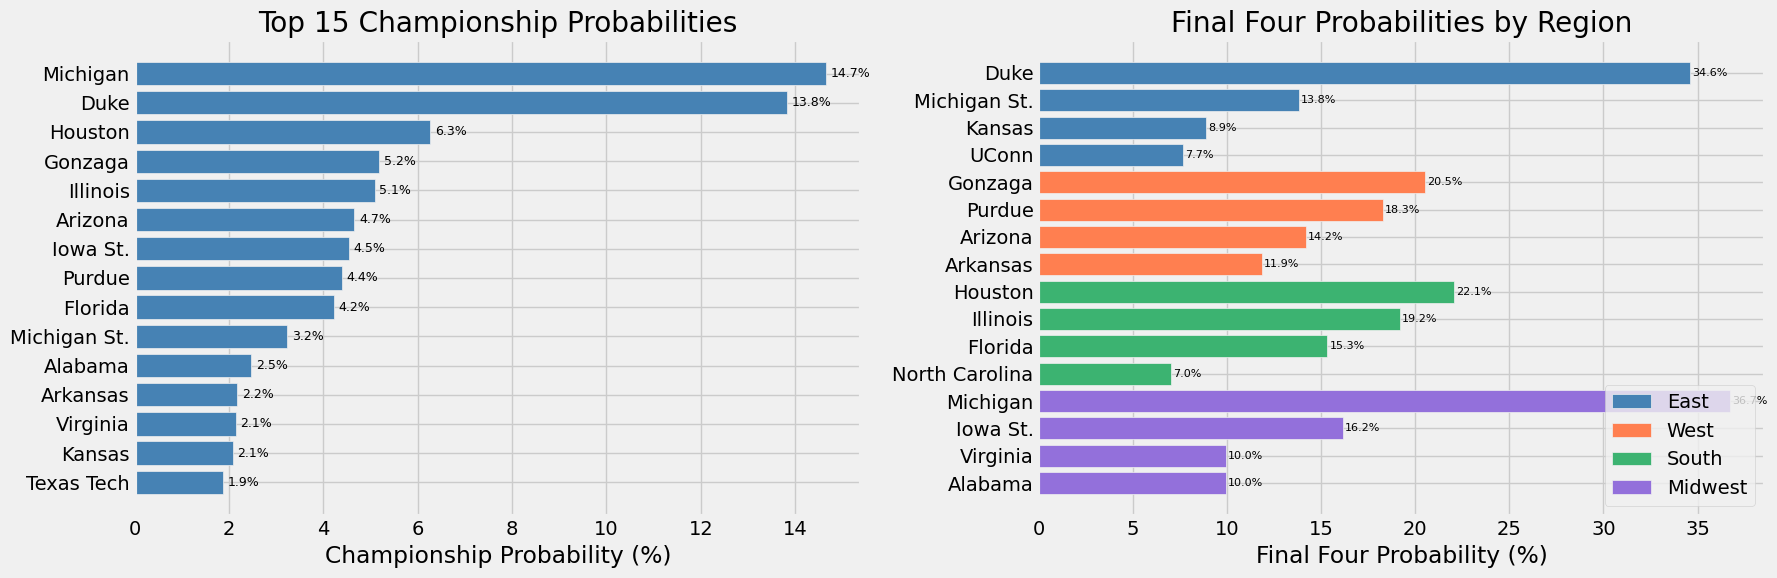

In [15]:
# Claude helped me out majorly for the predicting part, as I have no experience in making predictors or anything like that.

# provides seed matchups like commonly lead to upsets
seed_upset_rates = {
    (1, 16): 0.99, (2, 15): 0.94, (3, 14): 0.85,
    (4, 13): 0.79, (5, 12): 0.65, (6, 11): 0.63,
    (7, 10): 0.60, (8,  9): 0.51,
    # Round of 32 typical matchups
    (1,  8): 0.76, (1,  9): 0.74, (2,  7): 0.69,
    (2, 10): 0.67, (3,  6): 0.64, (3, 11): 0.62,
    (4,  5): 0.57, (4, 12): 0.60, (1, 16): 0.99,
}
# gives us the win probability
def win_prob(team1, team2, combined, seed1=None, seed2=None,
             srs_weight=0.5, hist_weight=0.2, seed_weight=0.3):
    rows1 = np.where(combined.column('Team') == team1)[0]
    rows2 = np.where(combined.column('Team') == team2)[0]
    if len(rows1) == 0 or len(rows2) == 0:
        return 0.5
    srs1 = combined.column('SRS')[rows1[0]]
    srs2 = combined.column('SRS')[rows2[0]]
    wp1  = combined.column('Win %')[rows1[0]]
    wp2  = combined.column('Win %')[rows2[0]]

    srs_prob  = 1 / (1 + np.exp(-(srs1 - srs2) / 10))
    hist_prob = np.clip(0.5 + (wp1 - wp2) / 200, 0.05, 0.95)

    if seed1 is not None and seed2 is not None:
        key = (min(seed1, seed2), max(seed1, seed2))
        seed_prob_high = seed_upset_rates.get(key, 0.5)
        seed_prob = seed_prob_high if seed1 < seed2 else 1 - seed_prob_high
        return srs_weight * srs_prob + hist_weight * hist_prob + seed_weight * seed_prob

    total = srs_weight + hist_weight
    return (srs_weight * srs_prob + hist_weight * hist_prob) / total

# runs the bracket 10,000 times
def simulate_bracket(bracket, combined, n=10000):
    all_teams = [t for matchups in bracket.values() for _, t1, _, t2 in matchups for t in [t1, t2]]

    region_ff_counts = {r: {t: 0 for _, t1, _, t2 in ms for t in [t1, t2]} for r, ms in bracket.items()}
    champion_counts  = {t: 0 for t in all_teams}
    r64_probs        = {}
    r32_probs        = {}

    for _ in np.arange(n):
        final_four = {}

        for region, matchups in bracket.items():
            # Round 1
            r64_winners = []
            r64_seeds   = []
            for s1, t1, s2, t2 in matchups:
                p = win_prob(t1, t2, combined, seed1=s1, seed2=s2)
                r64_probs[(t1, t2)] = p
                if np.random.random() < p:
                    r64_winners.append(t1)
                    r64_seeds.append(s1)
                else:
                    r64_winners.append(t2)
                    r64_seeds.append(s2)

            # Round 2
            r32_winners = []
            r32_seeds   = []
            for i in np.arange(0, len(r64_winners), 2):
                t1, t2 = r64_winners[i], r64_winners[i+1]
                s1, s2 = r64_seeds[i],   r64_seeds[i+1]
                p = win_prob(t1, t2, combined, seed1=s1, seed2=s2)
                # Only store if both teams are NOT original r64 opponents
                original_r64_pairs = [(t for _, t, _, _ in matchups)] 
                r32_probs[(region, i//2)] = (t1, t2, p)
                if np.random.random() < p:
                    r32_winners.append(t1)
                    r32_seeds.append(s1)
                else:
                    r32_winners.append(t2)
                    r32_seeds.append(s2)

            # Round 3
            s16_winners = []
            for i in np.arange(0, len(r32_winners), 2):
                p = win_prob(r32_winners[i], r32_winners[i+1], combined)
                winner = r32_winners[i] if np.random.random() < p else r32_winners[i+1]
                s16_winners.append(winner)

            # Round 4
            p = win_prob(s16_winners[0], s16_winners[1], combined)
            region_winner = s16_winners[0] if np.random.random() < p else s16_winners[1]
            final_four[region] = region_winner
            region_ff_counts[region][region_winner] += 1

        # Top 4
        regions = list(final_four.keys())
        p1  = win_prob(final_four[regions[0]], final_four[regions[1]], combined)
        sf1 = final_four[regions[0]] if np.random.random() < p1 else final_four[regions[1]]
        p2  = win_prob(final_four[regions[2]], final_four[regions[3]], combined)
        sf2 = final_four[regions[2]] if np.random.random() < p2 else final_four[regions[3]]

        # Championship
        p = win_prob(sf1, sf2, combined)
        champion = sf1 if np.random.random() < p else sf2
        champion_counts[champion] += 1

    # Results
    print("CHAMPION PROBABILITIES")
    champ_arr = np.array([champion_counts[t] for t in all_teams])
    champ_pct = champ_arr / n * 100
    top10_idx = np.argsort(champ_pct)[::-1][:10]
    for i in top10_idx:
        if champ_pct[i] > 0:
            print(f"  {all_teams[i]}: {round(champ_pct[i], 1)}%")

    print("\nFINAL FOUR PROBABILITIES")
    for region, counts in region_ff_counts.items():
        print(f"\n  {region}:")
        teams_r = np.array(list(counts.keys()))
        vals_r  = np.array(list(counts.values())) / n * 100
        top4    = np.argsort(vals_r)[::-1][:4]
        for i in top4:
            if vals_r[i] > 0:
                print(f"    {teams_r[i]}: {round(vals_r[i], 1)}%")
                
    print("\nROUND OF 32 WIN PROBABILITIES")
    for region in bracket:
        print(f"\n  {region}:")
        for key, (t1, t2, p) in r32_probs.items():
            if key[0] == region:
                print(f"    {t1} {round(p*100,1)}% vs {t2} {round((1-p)*100,1)}%")

    print("\nROUND OF 64 WIN PROBABILITIES")
    for region, matchups in bracket.items():
        print(f"\n  {region}:")
        for s1, t1, s2, t2 in matchups:
            p = r64_probs.get((t1, t2), 0.5)
            print(f"    ({s1}){t1} {round(p*100,1)}% vs ({s2}){t2} {round((1-p)*100,1)}%")

    # Visual Plots, again Claude helped me here as I don't have much experience in making plots like this yet
    top_n     = 15
    top_idx   = np.argsort(champ_pct)[::-1][:top_n]
    top_teams = np.array(all_teams)[top_idx]
    top_pcts  = champ_pct[top_idx]

    fig, axes = plots.subplots(1, 2, figsize=(18, 6))

    axes[0].barh(top_teams[::-1], top_pcts[::-1], color='steelblue')
    axes[0].set_xlabel('Championship Probability (%)')
    axes[0].set_title('Top 15 Championship Probabilities')
    for i, v in enumerate(top_pcts[::-1]):
        if v > 0.3:
            axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

    ff_teams, ff_pcts, ff_regions = [], [], []
    for region, counts in region_ff_counts.items():
        teams_r = np.array(list(counts.keys()))
        vals_r  = np.array(list(counts.values())) / n * 100
        top4    = np.argsort(vals_r)[::-1][:4]
        for i in top4:
            if vals_r[i] > 0:
                ff_teams.append(teams_r[i])
                ff_pcts.append(vals_r[i])
                ff_regions.append(region)

    ff_teams   = np.array(ff_teams)
    ff_pcts    = np.array(ff_pcts)
    colors     = {'East': 'steelblue', 'West': 'coral', 'South': 'mediumseagreen', 'Midwest': 'mediumpurple'}
    bar_colors = [colors[r] for r in ff_regions]

    axes[1].barh(ff_teams[::-1], ff_pcts[::-1], color=bar_colors[::-1])
    axes[1].set_xlabel('Final Four Probability (%)')
    axes[1].set_title('Final Four Probabilities by Region')
    for i, v in enumerate(ff_pcts[::-1]):
        if v > 1:
            axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=r) for r, c in colors.items()]
    axes[1].legend(handles=legend_elements, loc='lower right')

    plots.tight_layout()
    plots.show()

    return champion_counts, region_ff_counts, r64_probs, r32_probs

champion_counts, final_four_counts, r64_probs, r32_probs = simulate_bracket(bracket, combined)

In [17]:
# Claude's help again. I wanted to print the predicted bracket 
# ── Eric's 2026 Bracket Predictions ──────────────────────────────────────────
# Generated by simulation on 3/19/26
# Scoring: 80-320 pts | Tiebreaker: 124 total points in Championship Game

predicted_bracket = {
    'East': {
        'R64':    [('Duke', 'Siena'), ('Ohio St.', 'TCU'), ("St. John's", 'Northern Iowa'),
                   ('Kansas', 'Cal Baptist'), ('Louisville', 'South Florida'),
                   ('Michigan St.', 'North Dakota St.'), ('UCLA', 'UCF'), ('UConn', 'Furman')],
        'R32':    [('Duke', 'Ohio St.'), ("St. John's", 'Kansas'),
                   ('Louisville', 'Michigan St.'), ('UCLA', 'UConn')],
        'S16':    [('Duke', "St. John's"), ('Michigan St.', 'UConn')],
        'E8':     [('Duke', 'Michigan St.')],
        'Winner': 'Duke'
    },
    'South': {
        'R64':    [('Florida', 'PVAMU'), ('Clemson', 'Iowa'), ('Vanderbilt', 'McNeese'),
                   ('Nebraska', 'Troy'), ('North Carolina', 'VCU'),
                   ('Illinois', 'Penn'), ("Saint Mary's", 'Texas A&M'), ('Houston', 'Idaho')],
        'R32':    [('Florida', 'Clemson'), ('Vanderbilt', 'Nebraska'),
                   ('North Carolina', 'Illinois'), ("Saint Mary's", 'Houston')],
        'S16':    [('Clemson', 'Nebraska'), ('Illinois', 'Houston')],
        'E8':     [('Nebraska', 'Houston')],
        'Winner': 'Houston'
    },
    'West': {
        'R64':    [('Arizona', 'Long Island'), ('Villanova', 'Utah St.'),
                   ('Wisconsin', 'High Point'), ('Arkansas', 'Hawaii'),
                   ('BYU', 'Texas'), ('Gonzaga', 'Kennesaw St.'),
                   ('Miami (FL)', 'Missouri'), ('Purdue', 'Queens (N.c.)')],
        'R32':    [('Arizona', 'Villanova'), ('Wisconsin', 'Arkansas'),
                   ('BYU', 'Gonzaga'), ('Miami (FL)', 'Purdue')],
        'S16':    [('Arizona', 'Arkansas'), ('Gonzaga', 'Purdue')],
        'E8':     [('Arizona', 'Gonzaga')],
        'Winner': 'Gonzaga'
    },
    'Midwest': {
        'R64':    [('Michigan', 'HOW'), ('Georgia', 'Saint Louis'),
                   ('Texas Tech', 'Akron'), ('Alabama', 'Hofstra'),
                   ('Tennessee', 'SMU'), ('Virginia', 'Wright St.'),
                   ('Kentucky', 'Santa Clara'), ('Iowa St.', 'Tennessee St.')],
        'R32':    [('Michigan', 'Georgia'), ('Texas Tech', 'Alabama'),
                   ('Tennessee', 'Virginia'), ('Kentucky', 'Iowa St.')],
        'S16':    [('Michigan', 'Alabama'), ('Virginia', 'Iowa St.')],
        'E8':     [('Michigan', 'Iowa St.')],
        'Winner': 'Michigan'
    },
    'Final Four': {
        'Semifinal 1': ('Duke', 'Houston'),
        'Semifinal 2': ('Gonzaga', 'Michigan'),
        'Winner 1':    'Duke',
        'Winner 2':    'Michigan',
    },
    'Championship': {
        'Matchup':    ('Duke', 'Michigan'),
        'Champion':   'Michigan',
        'Location':   'Indianapolis, IN',
        'Tiebreaker': 124
    }
}

print("  ERIC'S 2026 MARCH MADNESS PREDICTIONS")
print("  Generated: 3/19/26")
for region in ['East', 'South', 'West', 'Midwest']:
    print(f"\n  {region} Winner: {predicted_bracket[region]['Winner']}")
print(f"\n  Final Four:")
print(f"    {predicted_bracket['Final Four']['Semifinal 1'][0]} vs {predicted_bracket['Final Four']['Semifinal 1'][1]} → {predicted_bracket['Final Four']['Winner 1']}")
print(f"    {predicted_bracket['Final Four']['Semifinal 2'][0]} vs {predicted_bracket['Final Four']['Semifinal 2'][1]} → {predicted_bracket['Final Four']['Winner 2']}")
print(f"\n  Championship: {predicted_bracket['Championship']['Matchup'][0]} vs {predicted_bracket['Championship']['Matchup'][1]}")
print(f"  Champion:     {predicted_bracket['Championship']['Champion']}")
print(f"  Location:     {predicted_bracket['Championship']['Location']}")
print(f"  Tiebreaker:   {predicted_bracket['Championship']['Tiebreaker']} total points")

  ERIC'S 2026 MARCH MADNESS PREDICTIONS
  Generated: 3/19/26

  East Winner: Duke

  South Winner: Houston

  West Winner: Gonzaga

  Midwest Winner: Michigan

  Final Four:
    Duke vs Houston → Duke
    Gonzaga vs Michigan → Michigan

  Championship: Duke vs Michigan
  Champion:     Michigan
  Location:     Indianapolis, IN
  Tiebreaker:   124 total points
